# Titanic Preprocessing with scikit‑learn (No CSV Writes)

This notebook demonstrates, using only **scikit‑learn** primitives:
1. Missing‑value handling (median for numeric, most‑frequent for categorical)
2. Categorical encodings: **Label/Ordinal** and **One‑Hot**
3. Feature scaling: **Min‑Max** and **Z‑score (StandardScaler)**
4. Row‑wise similarity & distance matrices:
   - Pearson’s correlation (feature‑feature, numeric)
   - Cosine similarity (rows, numeric standardized)
   - Jaccard similarity (rows, one‑hot categoricals)
   - Euclidean distance (rows, numeric standardized)

**Input path**: `/mnt/data/Lab2_titanic.csv` (change in the first code cell if needed)


In [2]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

DATA_PATH = Path('Lab2_titanic.csv') 
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Detect numeric vs categorical columns

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Numeric:', numeric_cols)
print('Categorical:', categorical_cols)

Numeric: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## 1) Missing values: median (numeric) & most‑frequent (categorical)

In [4]:
# Impute numeric
num_imputer = SimpleImputer(strategy='median')
X_num = num_imputer.fit_transform(df[numeric_cols]) if numeric_cols else np.empty((len(df), 0))

# Impute categorical
cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat = cat_imputer.fit_transform(df[categorical_cols]) if categorical_cols else np.empty((len(df), 0))

df_num_imputed = pd.DataFrame(X_num, columns=numeric_cols, index=df.index)
df_cat_imputed = pd.DataFrame(X_cat, columns=categorical_cols, index=df.index)

df_imputed = pd.concat([df_num_imputed, df_cat_imputed], axis=1)[df.columns]
df_imputed.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,B96 B98,S
1,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C
2,3.0,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,B96 B98,S
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S
4,5.0,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,B96 B98,S


## 2) Categorical Encoding
### 2.a Ordinal (Label) Encoding

In [5]:
if categorical_cols:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_ord = ord_enc.fit_transform(df_cat_imputed)
    ord_colnames = [c + '_label' for c in categorical_cols]
    df_label = pd.concat([
        df_num_imputed.reset_index(drop=True),
        pd.DataFrame(X_cat_ord, columns=ord_colnames)
    ], axis=1)
else:
    df_label = df_num_imputed.copy()

df_label.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Name_label,Sex_label,Ticket_label,Cabin_label,Embarked_label
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500,108.0,1.0,523.0,47.0,2.0
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833,190.0,0.0,596.0,81.0,0.0
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250,353.0,0.0,669.0,47.0,2.0
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000,272.0,0.0,49.0,55.0,2.0
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500,15.0,1.0,472.0,47.0,2.0


### 2.b One‑Hot Encoding

In [6]:
from sklearn.preprocessing import OneHotEncoder

if categorical_cols:
    oh_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    X_cat_oh = oh_enc.fit_transform(df_cat_imputed)
    oh_cols = oh_enc.get_feature_names_out(categorical_cols)
    df_onehot = pd.concat([
        df_num_imputed.reset_index(drop=True),
        pd.DataFrame(X_cat_oh, columns=oh_cols, index=df.index)
    ], axis=1)
else:
    df_onehot = df_num_imputed.copy()

df_onehot.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbing, Mr. Anthony","Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_C,Embarked_Q,Embarked_S
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 3) Feature Scaling on Numeric Features Only
We keep two separate scaled matrices: **Min‑Max** and **Standard (Z‑score)**.

In [7]:
mm = MinMaxScaler()
X_minmax = mm.fit_transform(df_num_imputed) if numeric_cols else np.empty((len(df), 0))
df_minmax = pd.DataFrame(X_minmax, columns=numeric_cols, index=df.index)

ss = StandardScaler(with_mean=True, with_std=True)
X_z = ss.fit_transform(df_num_imputed) if numeric_cols else np.empty((len(df), 0))
df_zscore = pd.DataFrame(X_z, columns=numeric_cols, index=df.index)

print('MinMax shape:', df_minmax.shape, '| Z-score shape:', df_zscore.shape)
df_zscore.head()

MinMax shape: (891, 7) | Z-score shape: (891, 7)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.730108,-0.789272,0.827377,-0.565736,0.432793,-0.473674,-0.502445
1,-1.726220,1.266990,-1.566107,0.663861,0.432793,-0.473674,0.786845
2,-1.722332,1.266990,0.827377,-0.258337,-0.474545,-0.473674,-0.488854
3,-1.718444,1.266990,-1.566107,0.433312,0.432793,-0.473674,0.420730
4,-1.714556,-0.789272,0.827377,0.433312,-0.474545,-0.473674,-0.486337


## 4) Similarity & Distance Matrices
We will compute on a **subset of rows** (first 50) to keep the matrices compact in the notebook output. Increase if needed.

In [8]:
subset = min(50, len(df))
idx = df.index[:subset]

# 4.1 Pearson correlation (feature-feature on numeric)
pearson_corr = df_num_imputed.corr(method='pearson') if len(numeric_cols) else pd.DataFrame()
pearson_corr.round(2).head(10)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,-0.04,0.03,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.34,-0.06,-0.04,0.08,0.26
Pclass,-0.04,-0.34,1.00,-0.34,0.08,0.02,-0.55
Age,0.03,-0.06,-0.34,1.00,-0.23,-0.17,0.10
SibSp,-0.06,-0.04,0.08,-0.23,1.00,0.41,0.16
Parch,-0.00,0.08,0.02,-0.17,0.41,1.00,0.22
Fare,0.01,0.26,-0.55,0.10,0.16,0.22,1.00


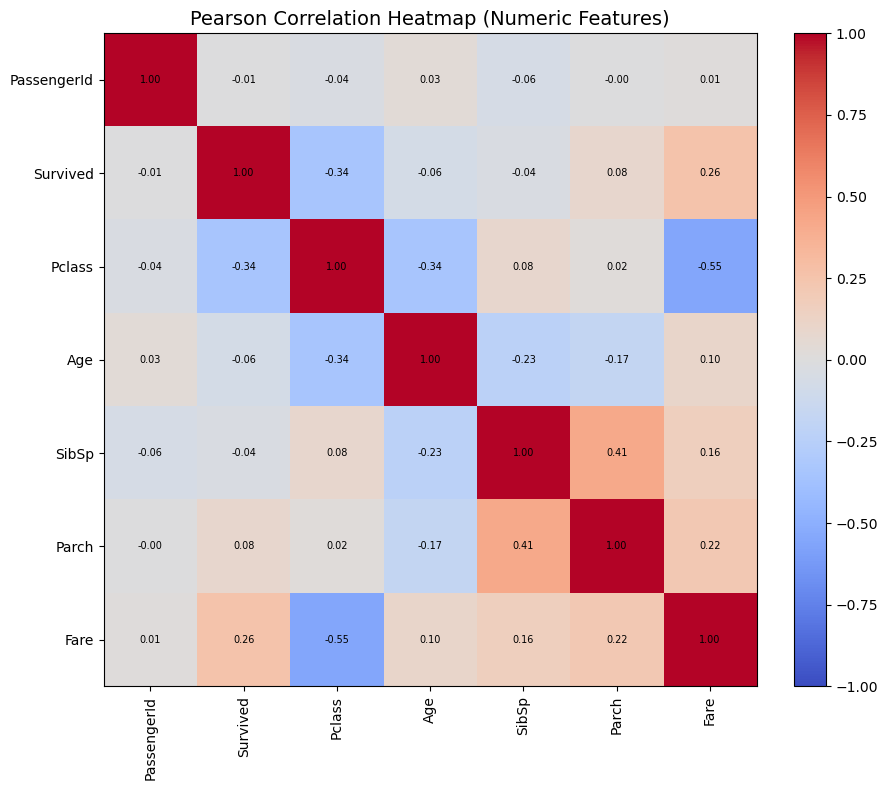

In [9]:
import matplotlib.pyplot as plt

# Draw heatmap of Pearson correlation
if not pearson_corr.empty:
    plt.figure(figsize=(10, 8))
    im = plt.imshow(pearson_corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # Axis ticks
    plt.xticks(range(len(pearson_corr.columns)), pearson_corr.columns, rotation=90)
    plt.yticks(range(len(pearson_corr.columns)), pearson_corr.columns)

    # Annotate values
    for i in range(len(pearson_corr.columns)):
        for j in range(len(pearson_corr.columns)):
            plt.text(
                j, i, f"{pearson_corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=7
            )

    plt.title("Pearson Correlation Heatmap (Numeric Features)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [10]:
# 4.2 Cosine similarity (row-row) on standardized numeric features
if len(numeric_cols):
    cos_sim = cosine_similarity(df_zscore.iloc[:subset])
    cos_sim_df = pd.DataFrame(cos_sim, index=idx.astype(str), columns=idx.astype(str))
    cos_sim_df.iloc[:10, :10].round(3)
else:
    pd.DataFrame()

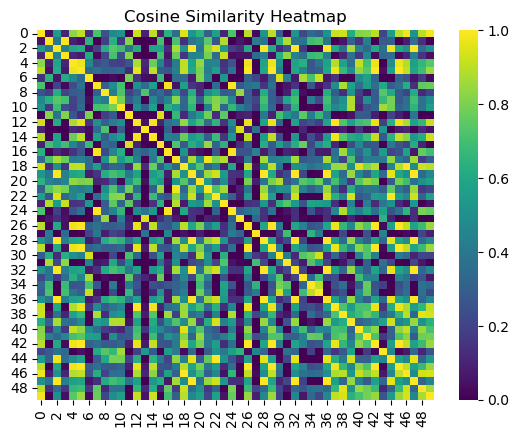

In [11]:
import seaborn as sns, matplotlib.pyplot as plt
sns.heatmap(cos_sim, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Heatmap")
plt.show()

In [12]:
# 4.3 Jaccard similarity (row-row) on one-hot categorical features
if df_onehot.shape[1] > len(numeric_cols):
    # isolate only the one-hot part
    oh_only_cols = [c for c in df_onehot.columns if c not in numeric_cols]
    X_bin = df_onehot.loc[idx, oh_only_cols].to_numpy(dtype=int)
    # pairwise_distances with metric='jaccard' returns distance; similarity = 1 - distance
    jac_dist = pairwise_distances(X_bin, metric='jaccard') if X_bin.shape[1] > 0 else np.ones((subset, subset))
    jac_sim = 1.0 - jac_dist
    jac_sim_df = pd.DataFrame(jac_sim, index=idx.astype(str), columns=idx.astype(str))
    jac_sim_df.iloc[:10, :10].round(3)
else:
    pd.DataFrame()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


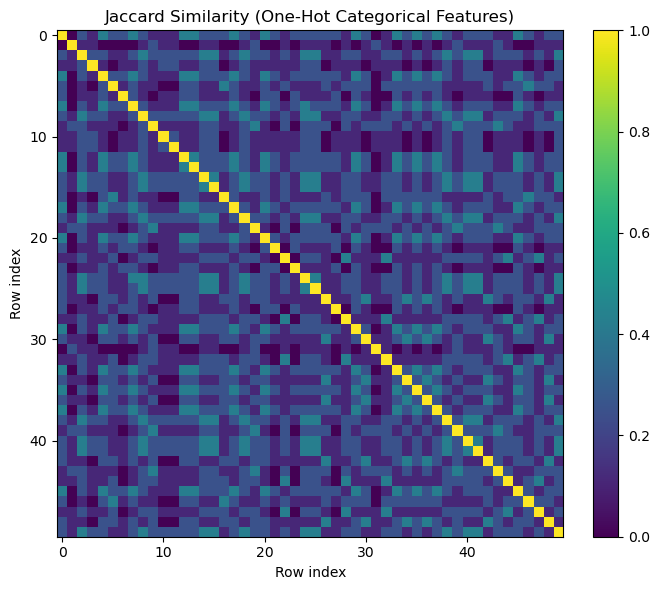

/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_9912/2588734262.py:47: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dis, method="average")               # hierarchical clustering


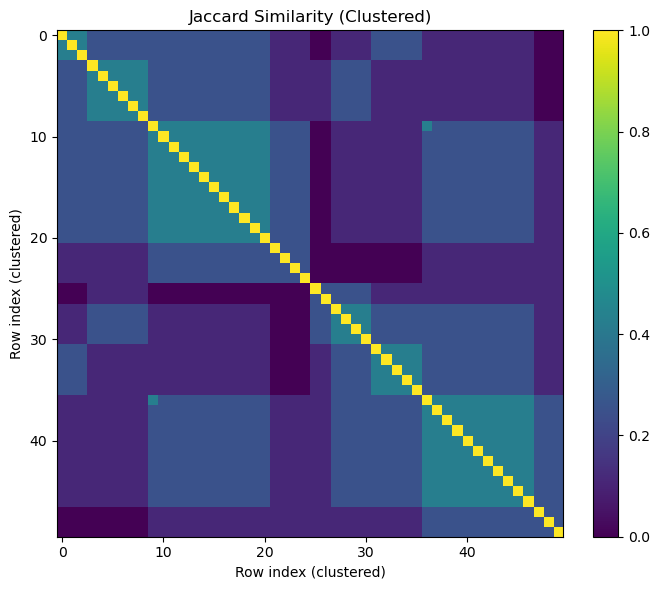

In [15]:
# --- 4.3 Jaccard similarity (row–row) on one-hot categorical features + visualization ---

from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: clustered heatmap imports
from scipy.cluster.hierarchy import linkage, leaves_list

# 1) Identify one-hot columns by removing numeric feature names
oh_only_cols = [c for c in df_onehot.columns if c not in numeric_cols]

# 2) Guard clauses for empty cases
if len(oh_only_cols) == 0:
    print("No one-hot categorical columns found. Skipping Jaccard.")
    jac_sim_df = pd.DataFrame()  # empty
else:
    # 3) Build binary matrix for a subset of rows (idx already defined)
    X_bin = df_onehot.loc[idx, oh_only_cols].to_numpy(dtype=int)

    # If the one-hot part is accidentally empty in the chosen subset
    if X_bin.shape[1] == 0:
        print("One-hot matrix has zero columns for the selected subset. Skipping Jaccard.")
        jac_sim_df = pd.DataFrame()
    else:
        # 4) Jaccard distance (sklearn returns distance) → convert to similarity
        jac_dist = pairwise_distances(X_bin, metric='jaccard')
        jac_sim = 1.0 - jac_dist

        # 5) Nice labeled DataFrame
        jac_sim_df = pd.DataFrame(jac_sim, index=idx.astype(str), columns=idx.astype(str))

        # ---- A) Plain heatmap (fast, direct view)
        plt.figure(figsize=(8, 6))
        im = plt.imshow(jac_sim_df, vmin=0, vmax=1)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.title("Jaccard Similarity (One-Hot Categorical Features)")
        plt.xlabel("Row index")
        plt.ylabel("Row index")
        plt.tight_layout()
        plt.show()

        # ---- B) Clustered heatmap (reveals groups/blocks)
        # Use 1 - similarity as dissimilarity for clustering
        dis = 1.0 - jac_sim
        Z = linkage(dis, method="average")               # hierarchical clustering
        order = leaves_list(Z)                           # leaf order
        jac_sim_ord = jac_sim_df.iloc[order, :].iloc[:, order]

        plt.figure(figsize=(8, 6))
        im2 = plt.imshow(jac_sim_ord, vmin=0, vmax=1)
        plt.colorbar(im2, fraction=0.046, pad=0.04)
        plt.title("Jaccard Similarity (Clustered)")
        plt.xlabel("Row index (clustered)")
        plt.ylabel("Row index (clustered)")
        plt.tight_layout()
        plt.show()

# Optional: thresholded “adjacency” if you want a graph later
# thr = 0.7
# A = (jac_sim_df.values >= thr).astype(int)  # adjacency at threshold

In [13]:
# 4.4 Euclidean distance (row-row) on standardized numeric features
if len(numeric_cols):
    euc = pairwise_distances(df_zscore.iloc[:subset], metric='euclidean')
    euc_df = pd.DataFrame(euc, index=idx.astype(str), columns=idx.astype(str))
    euc_df.iloc[:10, :10].round(3)
else:
    pd.DataFrame()

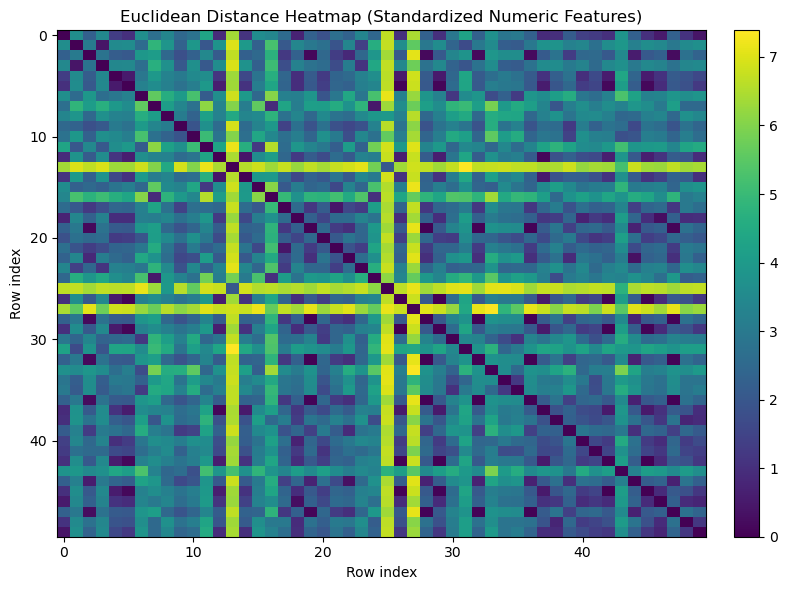

/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_9912/2249996294.py:35: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(euc, method="average")          # hierarchical clustering on distances


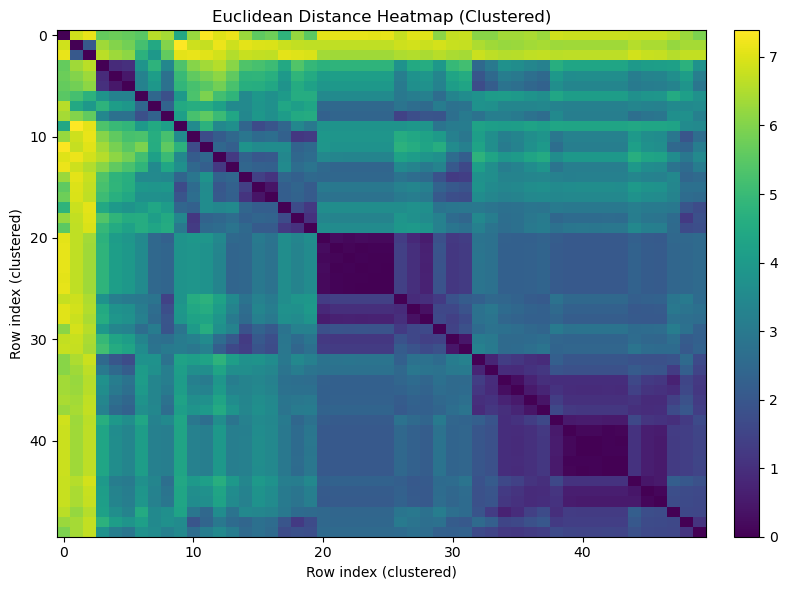

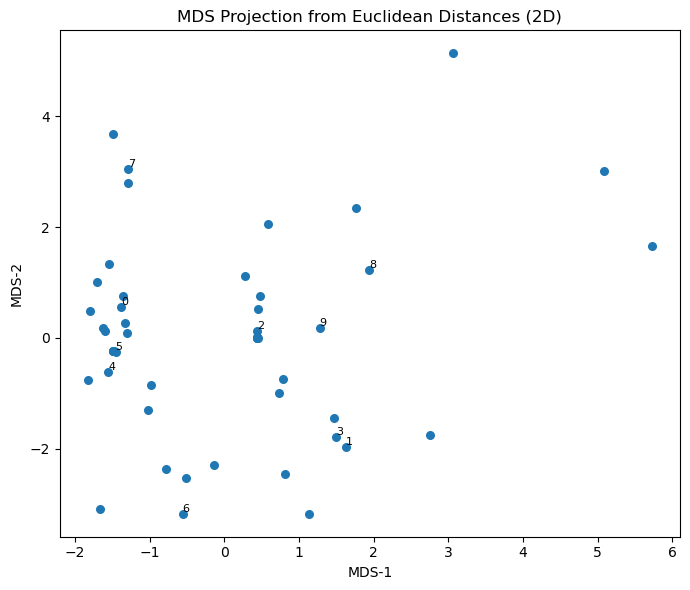

In [16]:
# --- 4.4 Euclidean distance (row–row) on standardized numeric features + visualization ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import linkage, leaves_list

# We expect df_zscore (standardized numeric features), subset size, and idx already defined.
# df_zscore must contain only numeric columns (it does in your pipeline).

# 1) Guard clauses
if df_zscore is None or df_zscore.shape[1] == 0:
    print("No numeric features available for Euclidean distance. Skipping.")
    euc_df = pd.DataFrame()
else:
    # 2) Compute Euclidean distance on the chosen subset
    X = df_zscore.iloc[:subset]  # standardized numeric rows
    euc = pairwise_distances(X, metric="euclidean")
    euc_df = pd.DataFrame(euc, index=idx.astype(str), columns=idx.astype(str))

    # ---- A) Plain heatmap (distance: smaller = closer)
    plt.figure(figsize=(8, 6))
    im = plt.imshow(euc_df, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Euclidean Distance Heatmap (Standardized Numeric Features)")
    plt.xlabel("Row index")
    plt.ylabel("Row index")
    plt.tight_layout()
    plt.show()

    # ---- B) Clustered heatmap (reveals tight groups)
    # Use Euclidean distance directly for hierarchical clustering
    Z = linkage(euc, method="average")          # hierarchical clustering on distances
    order = leaves_list(Z)                      # leaf order from dendrogram
    euc_ord = euc_df.iloc[order, :].iloc[:, order]

    plt.figure(figsize=(8, 6))
    im2 = plt.imshow(euc_ord, aspect="auto")
    plt.colorbar(im2, fraction=0.046, pad=0.04)
    plt.title("Euclidean Distance Heatmap (Clustered)")
    plt.xlabel("Row index (clustered)")
    plt.ylabel("Row index (clustered)")
    plt.tight_layout()
    plt.show()

    # ---- C) MDS 2-D projection (intuitive map of samples)
    # MDS tries to place points so pairwise distances ≈ Euclidean distances
    try:
        mds = MDS(
            n_components=2,
            dissimilarity="precomputed",
            random_state=42,
            n_init=4,
            max_iter=600
        )
        coords = mds.fit_transform(euc)  # shape: (subset, 2)

        plt.figure(figsize=(7, 6))
        plt.scatter(coords[:, 0], coords[:, 1], s=30)
        # Optional: annotate a few points for reference (e.g., first 10)
        for k in range(min(10, len(idx))):
            plt.text(coords[k, 0], coords[k, 1], str(idx[k]), fontsize=8, ha="left", va="bottom")
        plt.title("MDS Projection from Euclidean Distances (2D)")
        plt.xlabel("MDS-1")
        plt.ylabel("MDS-2")
        plt.tight_layout()
        plt.show()
    except Exception as ex:
        print(f"MDS skipped due to: {ex}")

# Optional: nearest-neighbor graph idea (k-NN) if you want a graph later
# k = 5
# if not euc_df.empty:
#     nn_idx = np.argsort(euc, axis=1)[:, 1:k+1]  # exclude self (0th)
#     # Build adjacency or edge list as needed